# Klassifikation der Eigenwerte mit LazyClassifier (Train/Test + CV)

**Setup.** Features = Eigenwerte pro Run, Label = Fault-Klasse `0..20` (Integer,
**kein** One-Hot — lazypredict/sklearn erwarten 1D-Klassenlabels).

**Datenfluss.**
- **Train-Eigenwerte:** werden aus den CSVs gelesen, die
  `PCA_eigenwerte.ipynb` / `DyCA_Eigenwerte.ipynb` (Trainings-Analyse) schreiben.
- **Test-Eigenwerte:** werden **hier** aus den TEP-Test-CSVs berechnet — mit
  derselben per-Run-Funktion wie im Training, nur mit Cutoff **161** (Test:
  Fehler nach 8 h, 960 Samples/Run). Ergebnis wird als
  `*_eigenvalues_test.csv` gecached, damit Re-Runs nicht neu rechnen müssen.

  Zwei Punkte, die man dabei kennen sollte:
  - Beide Funktionen verwenden `X_scaled = X - X.mean()` (`global_mean`) —
    identisch zu den Analyse-Notebooks. Der `scaler` wird trotzdem gefittet
    und übergeben, bleibt aber ungenutzt, bis man umschaltet.
  - Die **Fensterlängen sind angeglichen**: die Test-Runs werden auf die
    Train-Fensterlänge gekürzt (Fault 0: 500 Samples, Fault 1–20: 480
    Post-Fault-Samples = 24 h nach Fehlereintritt) — im Code markiert als
    `TODO(Fenster-Angleich)`. Ohne die Kürzung stammten die Test-Eigenwerte
    aus 800/960-Sample-Fenstern, die Train-Eigenwerte aber aus 480/500.

So bleiben `PCA_eigenwerte.ipynb` / `DyCA_Eigenwerte.ipynb` reine
Trainings-Analyse; der Testdatensatz wird nur hier angefasst.

**Skalierung.** Aktuell aktiv: `X - X.mean()` (skalarer Gesamtmittelwert).
Wie in den Analyse-Notebooks ist die einzige umzuschaltende Stelle die Zeile
`X_scaled = ...` (`X - X.mean()` ↔ `scaler.transform(X)`) — hier in **beiden**
Funktionen. Beim Umschalten alle `*_eigenvalues_*.csv` neu erzeugen; die
Ergebnisse der Scaler-Variante liegen als `*_scaler.csv` archiviert.

**Bewertung.** `LazyClassifier(cv=5)`: 5-fache CV auf **Train** (Spalten
`… CV Mean/Std`) ist die Basis der **Modellauswahl**; die Spalten ohne `CV` sind
die **einmalige** Bewertung auf dem echten Testset. Drei Durchläufe: PCA, DyCA,
PCA+DyCA.

> Laufzeit/Speicher: die Test-Berechnung lädt `TEP_Faulty_Testing.csv` (3,4 GB)
> und rechnet PCA+DyCA über ~10000 Runs — **einmalig**, danach gecached. Plus
> ~30 Klassifizierer × 5 Folds × 3 Sätze (Server/über Nacht, ggf. tmux).

## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep). Dieses Notebook
enthält nur noch die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/spectra.py` | Registry der Verfahren, hier für die **Test**-Spektren gebraucht |
| `tep/eigen/classify.py` | Feature-Sätze, Modellvergleich, Confusion-Matrizen |

Die **Train**-Spektren kommen aus den Eigenwert-Notebooks (`*_eigenvalues_train*.csv`),
die **Test**-Spektren rechnet dieses Notebook selbst und legt sie als
`*_eigenvalues_test*.csv` ab — beim zweiten Lauf werden sie von dort
gelesen.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen; alle sechs Spektrum-Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen.


In [1]:
# ============================================================
# Imports - der gemeinsame Unterbau steckt im Paket tep
# ============================================================
# %load_ext autoreload
# %autoreload 2
import numpy as np
import pandas as pd

from tep.eigen import versions
from tep.eigen.classify import (class_distribution, confusion, counts,
                                feature_sets, plot_confusions,
                                report_confusions, run_lazyclassifier,
                                test_spectra, train_spectra)

print(versions())

tsfresh 0.21.2 | pandas 3.0.3 | numpy 2.4.6 | sklearn 1.9.0 | Kerne: 14


In [2]:
# ============================================================
# Konfiguration - die EINZIGE Stelle, an der geschraubt wird
# ============================================================
# METHODS bestimmt, WELCHE Spektren-CSVs geladen bzw. berechnet werden,
# PARAMS mit welchen Verfahrensparametern. Die DyCA-Werte muessen zu
# denen passen, mit denen DyCA_Eigenwerte.ipynb die Train-CSV erzeugt
# hat - sonst waeren Train- und Test-Spektren verschieden parametriert.
# Jedes Verfahren nimmt sich aus PARAMS nur, was es braucht.
DATA_DIR = "data_csv"          # Ordner mit den vier TEP-CSVs
SCALING_MODE = "global_mean"

METHODS = ["pca", "dyca"]
PARAMS = dict(dyca_m=2, dyca_n=4)

# Modellvergleich: 5-fache CV auf den TRAININGSdaten, Auswahl ueber
# "Balanced Accuracy CV Mean" - also ohne Blick aufs Testset.
CV_FOLDS = 5
SELECT_METRIC = "Balanced Accuracy CV Mean"
RANDOM_STATE = 42

## Spektren beschaffen

Die **Train**-Spektren erzeugen die Eigenwert-Notebooks (`PCA_eigenwerte.ipynb`, `DyCA_Eigenwerte.ipynb`) — sie müssen einmal gelaufen sein. Die **Test**-Spektren rechnet dieses Notebook und legt sie als CSV ab, damit ein zweiter Lauf die großen Test-CSVs nicht erneut anfassen muss.

Die Selektion hat ausschließlich Trainingsdaten gesehen — das Testset bleibt eine unverzerrte Generalisierungsschätzung.

In [3]:
# ============================================================
# Spektren laden: Train aus den Eigenwert-Notebooks, Test hier
# ============================================================
# Die Test-CSVs sind gross (3,4 GB fuer Faulty_Testing) - sie werden nur
# gelesen, wenn mindestens ein Verfahren wirklich rechnen muss. Beim
# zweiten Lauf kommt alles aus dem CSV-Cache.
#
# Wichtig ist die Fensterangleichung: im Training deckt ein Lauf 500
# (Fault 0) bzw. 480 (Fault != 0) Samples ab, im Test 960 bzw. 800.
# test_spectra() kuerzt entsprechend, sonst waeren Train- und
# Test-Spektren systematisch verschieden.
train = train_spectra(METHODS, SCALING_MODE, DATA_DIR)
test = test_spectra(METHODS, SCALING_MODE, DATA_DIR, **PARAMS)

# Ein Feature-Satz je Verfahren plus die Kombination (INNER JOIN auf
# fault/run - nur Laeufe, die alle Verfahren ueberlebt haben).
SETS = feature_sets(METHODS, train, test, combine=True)
for s in SETS:
    print(f"{s['name']:12s} {len(s['cols']):3d} Features | "
          f"train {s['train'].shape} test {s['test'].shape}")

PCA-Train geladen: (10500, 54)
DyCA-Train geladen: (10073, 54)
Lade TEP-Test-CSVs (gross, dauert) ...


Test-Rohdaten: (10080000, 55)


Berechne PCA-Spektrum pro Run:   0%|          | 0/10500 [00:00<?, ?it/s]

Erfolgreiche Runs: 10500
Fehler          : 0


PCA-Test gespeichert: (10500, 54) -> data_csv/pca_eigenvalues_test.csv


Berechne DyCA-Spektrum pro Run:   0%|          | 0/10500 [00:00<?, ?it/s]

Erfolgreiche Runs: 10094
Uebersprungen   : 0 (weniger als 9 Samples)
Fehler          : 406
Erste Fehler:
  fault=0, run=15: Complex eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=0, run=19: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=0, run=37: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=0, run=48: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=0, run=61: Complex eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.


DyCA-Test gespeichert: (10094, 54) -> data_csv/dyca_eigenvalues_test.csv
PCA           52 Features | train (10500, 54) test (10500, 54)
DyCA          52 Features | train (10073, 54) test (10094, 54)
PCA+DyCA     104 Features | train (10073, 106) test (10094, 106)


## Klassenverteilung prüfen

Bevor Modelle verglichen werden: sind die Klassen in Train und Test überhaupt gleich stark besetzt? DyCA verliert einzelne Läufe an numerischem Scheitern — fällt der Verlust auf wenige Fehlerklassen, ist der Vergleich mit PCA nicht mehr ganz fair.

In [4]:
# ============================================================
# Klassenverteilung in Train und Test
# ============================================================
# Die Verlust-Spalten zeigen, wo ein Verfahren Laeufe einbuesst (DyCA
# scheitert an einzelnen numerisch). Klassen mit hohem Verlust sind
# Kandidaten fuer einen Selektions-Bias.
dist = class_distribution(SETS)

print(dist.to_string())

             PCA_train  PCA_test  DyCA_train  DyCA_test  PCA+DyCA_train  PCA+DyCA_test  verlust_DyCA_train  verlust_PCA+DyCA_train  verlust_DyCA_test  verlust_PCA+DyCA_test
faultNumber                                                                                                                                                                 
0                  500       500         481        476             481            476                  19                      19                 24                     24
1                  500       500         487        486             487            486                  13                      13                 14                     14
2                  500       500         478        489             478            489                  22                      22                 11                     11
3                  500       500         493        483             493            483                   7                       7     

## Modellvergleich

`LazyClassifier` fittet rund 25 Klassifizierer je Feature-Satz. Ausgewählt wird über die **Train-CV** (`Balanced Accuracy CV Mean`), nicht über das Testergebnis — sonst wäre die Modellwahl selbst schon eine Anpassung an das Testset (Winner's Curse).

Balanced Accuracy ist der Macro-Recall und sieht Precision nicht; lazypredicts eigene `F1 Score`-Spalte ist die *gewichtete* Variante. Beide Zahlen sind mit Vorsicht zu lesen, die Confusion-Matrizen darunter sagen mehr.

In [5]:
# ============================================================
# Modellvergleich je Feature-Satz
# ============================================================
# Sortiert nach der Train-CV, nicht nach dem Testergebnis. Modelle ohne
# predict_proba bekommen keine CV-Werte (der ROC-AUC-Scorer scheitert und
# leert alle CV-Spalten) und landen am Tabellenende.
leaderboards = {s["name"]: run_lazyclassifier(s, CV_FOLDS, SELECT_METRIC,
                                              RANDOM_STATE)
                for s in SETS}

leaderboards[SETS[-1]["name"]]

=== PCA ===
Features: 52 | Train: 10500 | Test: 10500 | Klassen: 21 | cv=5


/home/annika/Dokumente/Daten/Promotion/06_Code/NicoGrötsch/Hs-Ansbach-CCS/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
/home/annika/Dokumente/Daten/Promotion/06_Code/NicoGrötsch/Hs-Ansbach-CCS/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
/home/annika/Dokumente/Daten/Promotion/06_Code/NicoGrötsch/Hs-Ansbach-CCS/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is de

/home/annika/Dokumente/Daten/Promotion/06_Code/NicoGrötsch/Hs-Ansbach-CCS/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


Hinweis: 8 Modelle ohne CV-Werte am Tabellenende (ROC-AUC-Scorer scheitert ohne predict_proba). Staerkste nach Test-BA: LinearSVC 0.9015, SVC 0.8938, PassiveAggressiveClassifier 0.8909
Leaderboard sortiert nach 'Balanced Accuracy CV Mean' (nur im Speicher, keine CSV).
=== DyCA ===
Features: 52 | Train: 10073 | Test: 10094 | Klassen: 21 | cv=5


/home/annika/Dokumente/Daten/Promotion/06_Code/NicoGrötsch/Hs-Ansbach-CCS/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


...

/home/annika/Dokumente/Daten/Promotion/06_Code/NicoGrötsch/Hs-Ansbach-CCS/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
/home/annika/Dokumente/Daten/Promotion/06_Code/NicoGrötsch/Hs-Ansbach-CCS/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


/home/annika/Dokumente/Daten/Promotion/06_Code/NicoGrötsch/Hs-Ansbach-CCS/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
/home/annika/Dokumente/Daten/Promotion/06_Code/NicoGrötsch/Hs-Ansbach-CCS/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


/home/annika/Dokumente/Daten/Promotion/06_Code/NicoGrötsch/Hs-Ansbach-CCS/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


Hinweis: 10 Modelle ohne CV-Werte am Tabellenende (ROC-AUC-Scorer scheitert ohne predict_proba). Staerkste nach Test-BA: LinearSVC 0.9306, Perceptron 0.9116, PassiveAggressiveClassifier 0.9115
Leaderboard sortiert nach 'Balanced Accuracy CV Mean' (nur im Speicher, keine CSV).


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Accuracy CV Mean,Accuracy CV Std,Balanced Accuracy CV Mean,Balanced Accuracy CV Std,ROC AUC CV Mean,ROC AUC CV Std,F1 Score CV Mean,F1 Score CV Std,Precision CV Mean,Precision CV Std,Recall CV Mean,Recall CV Std,Time Taken
Model,,,,,,,,,,,,,,,,,,,
CalibratedClassifierCV,0.930553,0.930588,0.995880,0.928888,0.929227,0.930553,0.928820,0.003211,0.929776,0.003271,0.995690,0.000368,0.927232,0.003403,0.927213,0.003577,0.928820,0.003211,20.983579
LogisticRegression,0.927680,0.927664,0.996256,0.926961,0.927180,0.927680,0.927728,0.002688,0.928645,0.002615,0.996077,0.000279,0.927038,0.002571,0.927447,0.002810,0.927728,0.002688,8.713361
RandomForestClassifier,0.922231,0.922325,0.995470,0.920270,0.920587,0.922231,0.922070,0.003727,0.923088,0.003618,0.995201,0.000426,0.920307,0.004296,0.920262,0.004445,0.922070,0.003727,13.291593
LinearDiscriminantAnalysis,0.919952,0.919879,0.995983,0.918845,0.918946,0.919952,0.918693,0.003227,0.919749,0.003290,0.995811,0.000281,0.917536,0.003449,0.917700,0.003921,0.918693,0.003227,3.647355
ExtraTreesClassifier,0.922825,0.922923,0.995211,0.920047,0.920342,0.922825,0.918496,0.004251,0.919587,0.004133,0.994963,0.000428,0.915101,0.004790,0.914586,0.004925,0.918496,0.004251,2.823293
BaggingClassifier,0.915990,0.916051,0.991087,0.915464,0.915309,0.915990,0.912638,0.004643,0.913639,0.004448,0.990850,0.001298,0.912154,0.005004,0.912697,0.004748,0.912638,0.004643,11.178712
DecisionTreeClassifier,0.893699,0.893711,0.944193,0.893994,0.894550,0.893699,0.898243,0.002963,0.899317,0.002765,0.946550,0.001559,0.897852,0.003039,0.897996,0.003490,0.898243,0.002963,2.182830
GaussianNB,0.869923,0.870199,0.990964,0.864880,0.870612,0.869923,0.871143,0.009865,0.872470,0.009636,0.991068,0.001136,0.866665,0.010324,0.869837,0.009385,0.871143,0.009865,0.545416
KNeighborsClassifier,0.853279,0.853687,0.974217,0.853930,0.859873,0.853279,0.844634,0.006076,0.845956,0.005956,0.972111,0.002116,0.845651,0.006201,0.852411,0.005617,0.844634,0.006076,1.221389


## Confusion-Matrizen

Ein **fester** Modelltyp (RandomForest) auf jedem Feature-Satz, auf dem gesamten Trainingssatz gefittet und **einmal** auf dem echten Testset ausgewertet. Die Unterschiede zwischen den Matrizen liegen damit allein an den Features, nicht an der Modellwahl.

In [6]:
# ============================================================
# Confusion-Matrizen: RandomForest auf jedem Feature-Satz
# ============================================================
# Fester Modelltyp ueber alle Saetze -> die Unterschiede zwischen den
# Matrizen liegen allein an den Features. Fit auf dem GANZEN
# Trainingssatz, danach genau EINE Auswertung auf dem echten Testset.
cm_results = confusion(SETS, RANDOM_STATE)

=== RandomForestClassifier | PCA ===
Features: 52 | Train: 10500 | Test: 10500 | Balanced Accuracy (Test): 0.8989
              precision    recall  f1-score   support

           0      0.485     0.356     0.411       500
           1      0.998     0.996     0.997       500
           2      1.000     1.000     1.000       500
           3      0.414     0.240     0.304       500
           4      0.876     0.960     0.916       500
           5      0.994     0.998     0.996       500
           6      0.998     1.000     0.999       500
           7      1.000     1.000     1.000       500
           8      0.994     0.990     0.992       500
           9      0.508     0.604     0.552       500
          10      0.994     0.988     0.991       500
          11      1.000     1.000     1.000       500
          12      0.989     0.912     0.949       500
          13      0.994     0.980     0.987       500
          14      1.000     1.000     1.000       500
          15      0.6

=== RandomForestClassifier | DyCA ===
Features: 52 | Train: 10073 | Test: 10094 | Balanced Accuracy (Test): 0.8166
              precision    recall  f1-score   support

           0      0.465     0.630     0.535       476
           1      0.976     0.988     0.982       486
           2      0.622     0.828     0.711       489
           3      0.278     0.182     0.220       483
           4      0.665     0.717     0.690       484
           5      0.957     0.961     0.959       489
           6      0.983     1.000     0.992       417
           7      0.990     0.998     0.994       487
           8      0.958     0.984     0.971       491
           9      0.356     0.292     0.321       483
          10      0.781     0.720     0.749       485
          11      0.931     0.952     0.942       483
          12      0.892     0.868     0.880       476
          13      0.969     0.901     0.934       484
          14      0.996     0.998     0.997       486
          15      0.

=== RandomForestClassifier | PCA+DyCA ===
Features: 104 | Train: 10073 | Test: 10094 | Balanced Accuracy (Test): 0.9223
              precision    recall  f1-score   support

           0      0.536     0.676     0.598       476
           1      1.000     1.000     1.000       486
           2      1.000     1.000     1.000       489
           3      0.472     0.344     0.398       483
           4      0.927     0.975     0.951       484
           5      0.998     1.000     0.999       489
           6      0.995     1.000     0.998       417
           7      1.000     1.000     1.000       487
           8      1.000     0.992     0.996       491
           9      0.543     0.513     0.528       483
          10      0.992     1.000     0.996       485
          11      1.000     1.000     1.000       483
          12      0.998     0.901     0.947       476
          13      0.994     0.990     0.992       484
          14      1.000     1.000     1.000       486
          15   

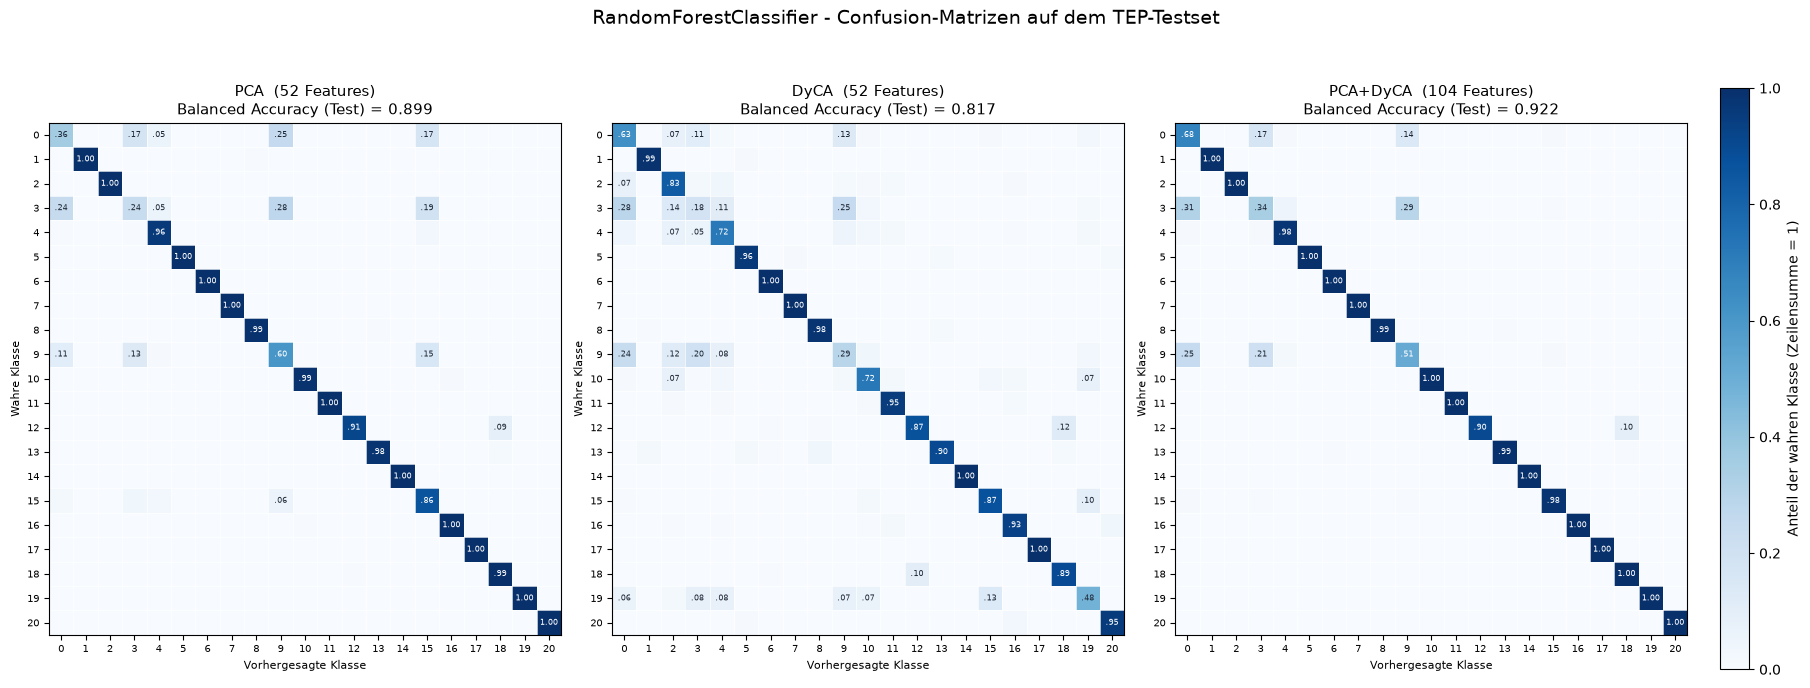

In [7]:
# ============================================================
# Plot: die Confusion-Matrizen nebeneinander
# ============================================================
# Zeilenweise normiert (Zeilensumme = 1): Zelle (i, j) ist der Anteil der
# wahren Klasse i, der als j vorhergesagt wurde - die Diagonale also der
# Recall. Gemeinsame Farbskala 0..1, damit die Panels vergleichbar sind.
_ = plot_confusions(cm_results, annot_min=0.05)

In [8]:
# ============================================================
# Groesste Verwechslungen und absolute Zaehlwerte
# ============================================================
report_confusions(cm_results, top_n=8)

cm_counts = counts(cm_results)
cm_counts[SETS[-1]["name"]]


=== PCA: groesste Verwechslungen (Top 8) ===
  wahr  3 -> vorhergesagt  9:  138 Runs (27.6% der Klasse)
  wahr  0 -> vorhergesagt  9:  126 Runs (25.2% der Klasse)
  wahr  3 -> vorhergesagt  0:  122 Runs (24.4% der Klasse)
  wahr  3 -> vorhergesagt 15:   94 Runs (18.8% der Klasse)
  wahr  0 -> vorhergesagt  3:   86 Runs (17.2% der Klasse)
  wahr  0 -> vorhergesagt 15:   83 Runs (16.6% der Klasse)
  wahr  9 -> vorhergesagt 15:   77 Runs (15.4% der Klasse)
  wahr  9 -> vorhergesagt  3:   63 Runs (12.6% der Klasse)

=== DyCA: groesste Verwechslungen (Top 8) ===
  wahr  3 -> vorhergesagt  0:  137 Runs (28.4% der Klasse)
  wahr  3 -> vorhergesagt  9:  119 Runs (24.6% der Klasse)
  wahr  9 -> vorhergesagt  0:  116 Runs (24.0% der Klasse)
  wahr  9 -> vorhergesagt  3:   97 Runs (20.1% der Klasse)
  wahr  3 -> vorhergesagt  2:   66 Runs (13.7% der Klasse)
  wahr 19 -> vorhergesagt 15:   65 Runs (13.5% der Klasse)
  wahr  0 -> vorhergesagt  9:   61 Runs (12.8% der Klasse)
  wahr  9 -> vorherges

,pred_0,pred_1,pred_2,pred_3,pred_4,pred_5,pred_6,pred_7,pred_8,pred_9,...,pred_11,pred_12,pred_13,pred_14,pred_15,pred_16,pred_17,pred_18,pred_19,pred_20
true_0,322,0,0,79,5,0,0,0,0,66,...,0,0,0,0,4,0,0,0,0,0
true_1,0,486,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_2,0,0,489,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_3,150,0,0,166,23,0,0,0,0,140,...,0,0,0,0,3,0,0,0,0,0
true_4,5,0,0,5,472,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
true_5,0,0,0,0,0,489,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_6,0,0,0,0,0,0,417,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_7,0,0,0,0,0,0,0,487,0,0,...,0,0,0,0,0,0,0,0,0,0
true_8,0,0,0,0,0,1,0,0,487,0,...,0,0,3,0,0,0,0,0,0,0
true_9,120,0,0,100,9,0,0,0,0,248,...,0,0,0,0,4,0,0,0,0,0
